## 2. Tekstexploratie: Woordanalyse
In dit notebook voeren we een woordenanalyse uit. We kijken naar welke woorden vaak voorkomen in de klachten, en ook welke woorden het meest voorkomen per productsector. 

### 2.1 Packages importeren 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter

from helpfuncties import (
    load_dataset,
    get_all_tokens,
    get_tokens_for_product
)

### 2.2 Dataset inladen en tokens ophalen

In [3]:
df = load_dataset()

In [4]:
# Alle tokens ophalen 
all_tokens = get_all_tokens(df)

In [5]:
# Tokens per product ophalen
tokens_per_product = {
    product: get_tokens_for_product(df, product)
    for product in df['Product'].unique()
}

- De tokens worden gepreprocessed met spaCy: tekst wordt opgeschoond (lowercase, geen cijfers/leestekens), daarna getokenized en gelemmatiseerd. Stopwoorden, ‘x’-tokens en 1-letter tokens worden gefilterd.

### 2.3 Globale woordfrequenties

In [6]:
# 20 meest voorkomende tokens van alle tokens ophalen
Counter(all_tokens).most_common(20)

[('credit', 20428),
 ('account', 20260),
 ('payment', 14497),
 ('report', 12749),
 ('pay', 11741),
 ('loan', 10210),
 ('bank', 9839),
 ('tell', 9631),
 ('receive', 9564),
 ('call', 9476),
 ('time', 8929),
 ('debt', 8773),
 ('send', 8084),
 ('information', 7283),
 ('company', 7275),
 ('card', 7235),
 ('mortgage', 6913),
 ('say', 6359),
 ('letter', 6278),
 ('state', 6242)]

- Veel voorkomende woorden zijn vaak domeinspecifiek, maar niet per se onderscheidend tussen productsectoren. Daarom wordt in de stappen hierna gekeken naar woordgebruik per productsector. 

### 2.4 Woordfrequenties per productsector

In [7]:
product_sector_woord_frequenties = {} # Dictionary met per productsector de woordfrequenties (token : aantal)

# Bepaal per productsector hoe vaak elk woord voorkomt
for product in df['Product'].unique():
    tokens = tokens_per_product[product]
    word_counts = Counter(tokens)
    product_sector_woord_frequenties[product] = word_counts

In [8]:
# Frequentietabel maken van woorden per productsector. Laat per productsector zien hoe vaak elk woord voorkomt
freq_tabel = (
    pd.DataFrame(product_sector_woord_frequenties)
    .fillna(0)  # Woorden die in een sector niet voorkomen krijgen frequentie 0
    .astype(int) # waarden omzetten naar integer, voorkomt floats door fillna 
)

freq_tabel.head()

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
deposit,1105,46,106,134,89,24
account,5211,886,3578,2480,3814,4291
day,982,550,900,1765,1087,827
different,150,78,188,394,320,182
company,276,522,797,1914,2609,1157


In [9]:
# frequentietabel opslaan als csv met token als index kolom
freq_tabel.to_csv("woordfrequenties_per_product.csv", index_label='token') 

### 2.5 Meest voorkomende woorden per productsector (tabel)

In [10]:
# Top 15 meest voorkomende woorden per productsector ophalen
top_words_per_product = {
    product: Counter(tokens_per_product[product]).most_common(15)
    for product in df['Product'].unique()
}

# DataFrame maken van de top woorden per productsector
top_words_df = pd.DataFrame({
    product: [w for w, _ in words]
    for product, words in top_words_per_product.items()
})

top_words_df

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
0,account,payment,credit,payment,debt,credit
1,bank,loan,card,loan,credit,report
2,check,pay,account,mortgage,account,account
3,tell,credit,payment,pay,call,information
4,fee,car,charge,home,collection,dispute
5,money,account,pay,receive,report,remove
6,charge,call,bank,time,pay,equifax
7,card,tell,tell,tell,company,file
8,deposit,time,receive,bank,receive,experian
9,receive,report,call,send,tell,send


- De topwoorden laten zien dat er overlap is in algemeen woordgebruik tussen productsectoren.

### 2.6 WordCloud - alle klachten 

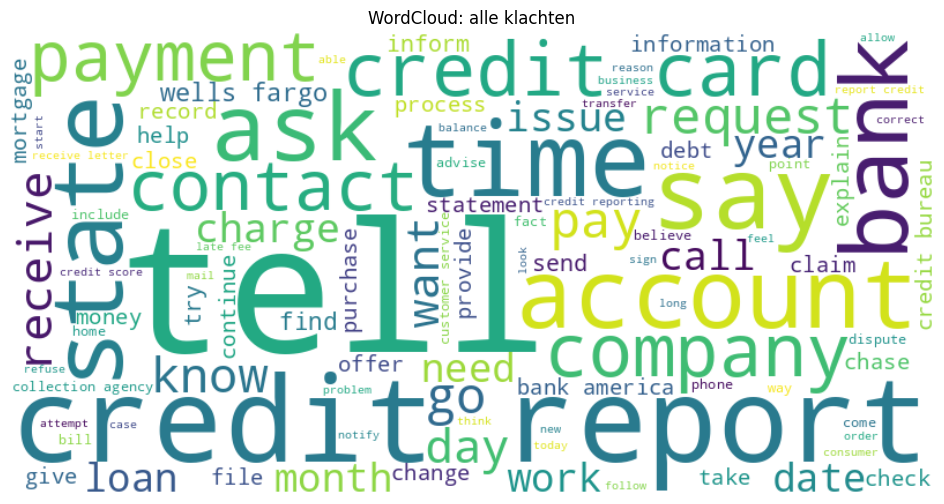

In [11]:
text_blob = " ".join(all_tokens) # Alle tokens samenvoegen tot één grote tekst

# Word cloud genereren voor alle klachten
wc_all = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text_blob)

plt.figure(figsize=(12,6))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud: alle klachten")
plt.show()

### 2.7 WordClouds per productsector

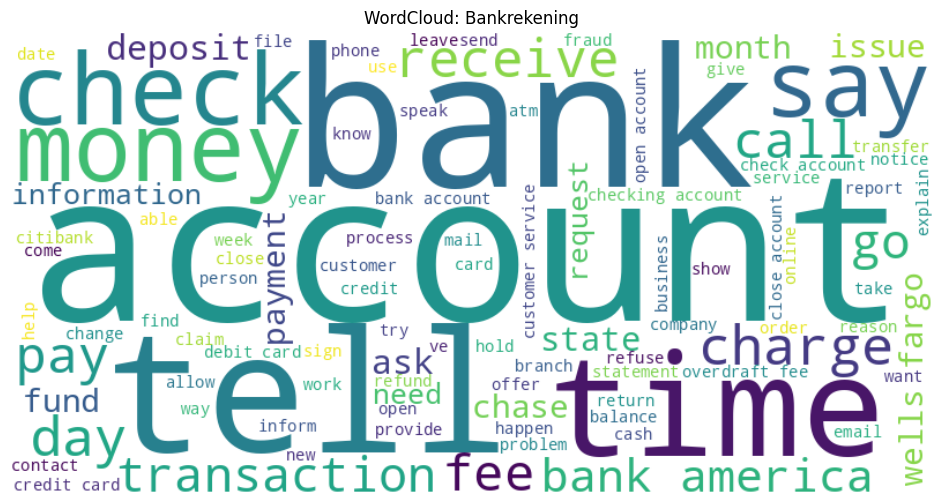

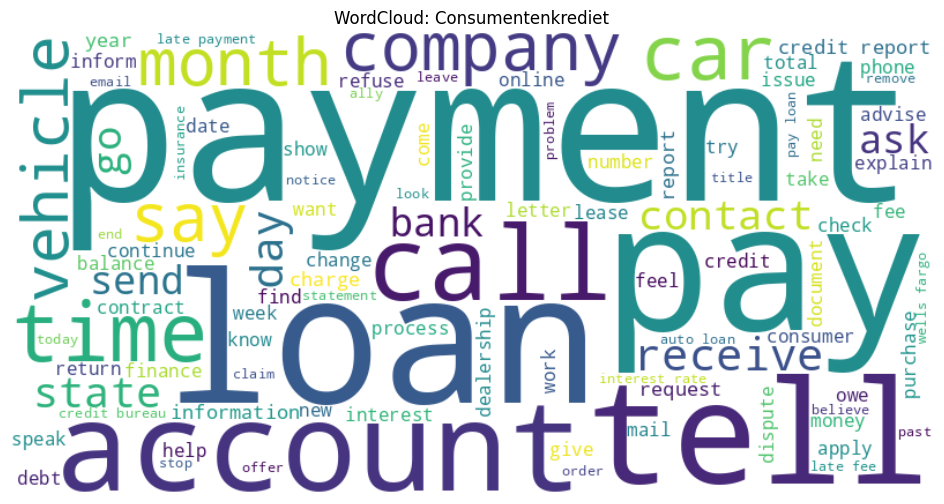

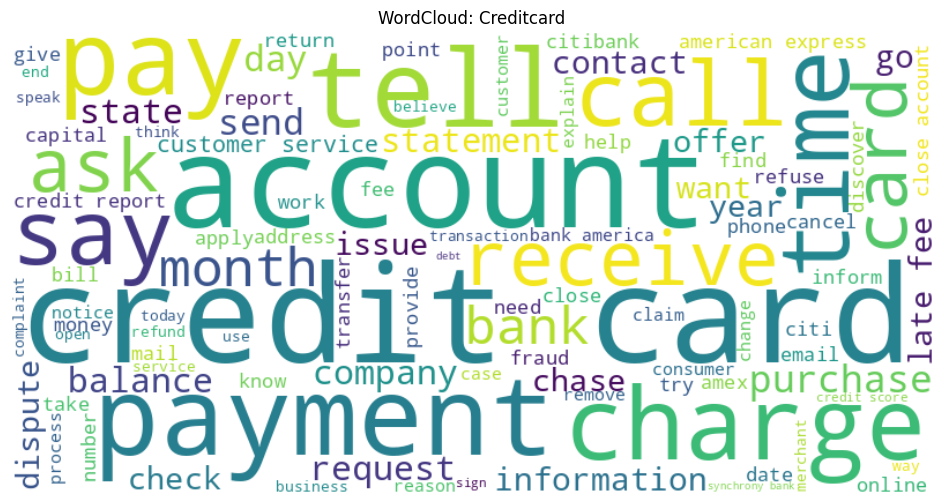

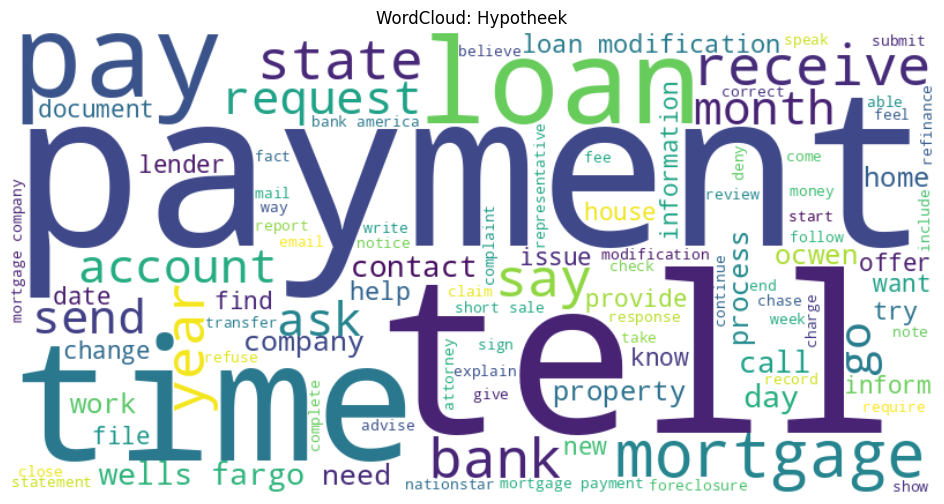

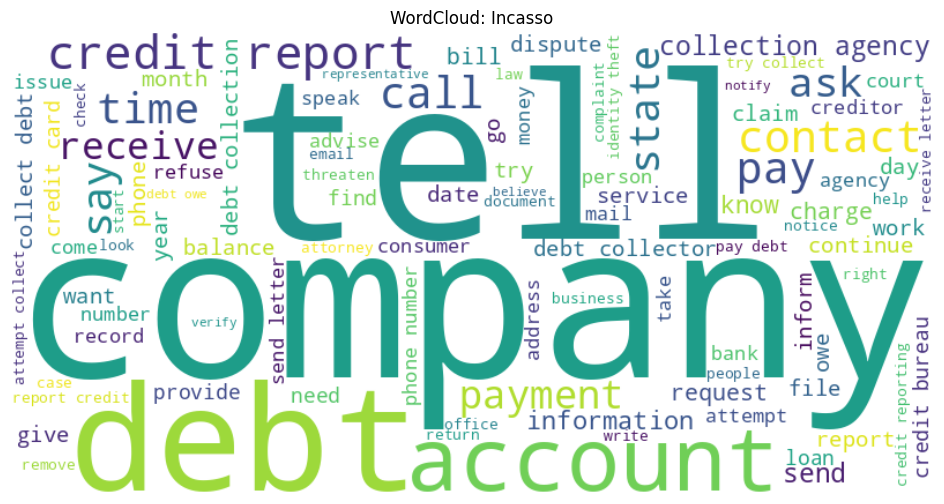

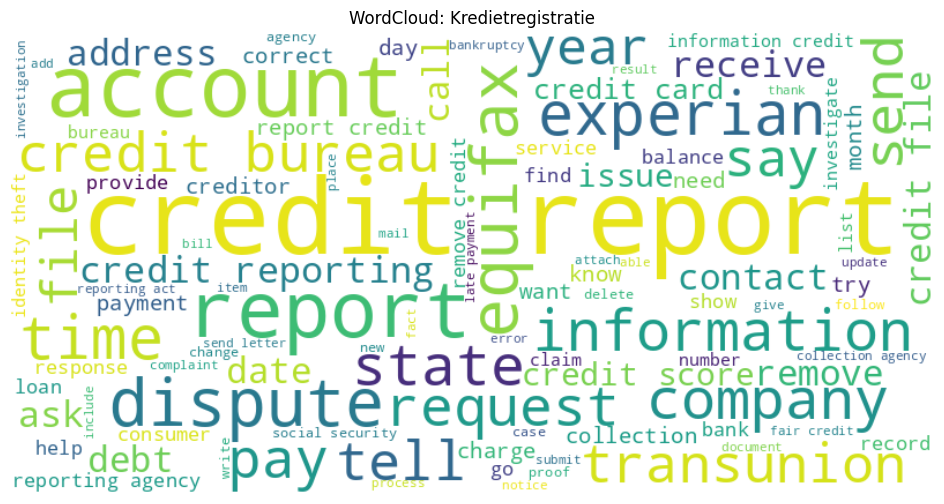

In [12]:
# Word clouds genereren per productsector en plotten met for loop
for product in sorted(tokens_per_product):
    tokens = tokens_per_product[product]
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100
    ).generate(" ".join(tokens))
    
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud: {product}")
    plt.axis("off")
    plt.show()